In [1]:
import tensorflow as tf
import numpy as np

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [17]:
!pip install "matplotlib>=3.8.4,<3.10.0"

  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp310-cp310-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 7.8/7.8 MB 48.2 MB/s  0:00:00
Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp310-cp310-win_amd64.whl (1.6 MB)
Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl (73 kB)
Using cached pillow-12.2.0-cp310-cp310-win_amd64.whl (7.1 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ----- ---------------------------------- 1/7 [pillow]
   ---

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

# GENERADOR DE DATOS DE SATÉLITE OPTIMIZADO
class GeneradorParchesTFG(Sequence):
    def __init__(self, carpeta_parches, lista_archivos, batch_size=64, shuffle=True):
        self.carpeta = carpeta_parches
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.archivos_X = lista_archivos
        self.num_clases = 19
        self.indices = np.arange(len(self.archivos_X))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.archivos_X) / self.batch_size))

    def __getitem__(self, index):
        indices_batch = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        
        batch_X = []
        batch_Y_porcentajes = []
        
        for idx in indices_batch:
            nom_X = self.archivos_X[idx]
            nom_Y = nom_X.replace('_X.npy', '_Y.npy')
            
            parche_X = np.load(os.path.join(self.carpeta, nom_X)).astype(np.float32)
            parche_Y = np.load(os.path.join(self.carpeta, nom_Y))
            
            if parche_X.shape[0] == 4:
                parche_X = np.transpose(parche_X, (1, 2, 0))
            
            parche_X = parche_X[:48, :48, :]
            parche_Y = parche_Y[:48, :48]
            
            for c in range(parche_X.shape[-1]):
                min_val = np.min(parche_X[:,:,c])
                max_val = np.max(parche_X[:,:,c])
                if max_val > min_val:
                    parche_X[:,:,c] = (parche_X[:,:,c] - min_val) / (max_val - min_val)
                else:
                    parche_X[:,:,c] = 0.0
            
            frecuencias = np.zeros(self.num_clases, dtype=np.float32)
            valores, counts = np.unique(parche_Y, return_counts=True)
            total_pixeles = parche_Y.size
            
            for v, c in zip(valores, counts):
                if 0 <= v < self.num_clases:
                    frecuencias[v] = c / total_pixeles
            
            suma_frec = np.sum(frecuencias)
            if float(suma_frec) == 0.0:
                continue
                
            frecuencias = frecuencias / suma_frec
            
            batch_X.append(parche_X)
            batch_Y_porcentajes.append(frecuencias)
            
        if len(batch_X) == 0:
            return np.zeros((1, 48, 48, 4), dtype=np.float32), np.zeros((1, self.num_clases), dtype=np.float32)
            
        return np.array(batch_X), np.array(batch_Y_porcentajes)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# PREPARACIÓN ESTRATIFICADA DEL DATASET (80/20)
carpeta_dataset = r"D:\Jorge\dataset_parches_50x50\dataset_parches_50x50"
todos_los_X = sorted([f for f in os.listdir(carpeta_dataset) if f.endswith('_X.npy')])

# Usamos los primeros 50k archivos disponibles
np.random.seed(4215) 
np.random.shuffle(todos_los_X)
archivos_prueba = todos_los_X[:750000]

print("Calculando categorías predominantes para la estratificación...")
categorias_predominantes = []
for nom_X in archivos_prueba:
    nom_Y = nom_X.replace('_X.npy', '_Y.npy')
    parche_Y = np.load(os.path.join(carpeta_dataset, nom_Y))
    valores, counts = np.unique(parche_Y, return_counts=True)
    clase_principal = valores[np.argmax(counts)]
    categorias_predominantes.append(clase_principal)

categorias_predominantes = np.array(categorias_predominantes)

# Reparto del 80% y 20% manteniendo proporciones idénticas de categorías
archivos_train, archivos_val = train_test_split(
    archivos_prueba, 
    test_size=0.2, 
    stratify=categorias_predominantes, 
    random_state=4215
)

generador_train = GeneradorParchesTFG(carpeta_dataset, archivos_train, batch_size=64, shuffle=True)
generador_val = GeneradorParchesTFG(carpeta_dataset, archivos_val, batch_size=64, shuffle=False)

# ==========================================
# 3. ARQUITECTURA RED CONVOLUCIONAL (48x48x4)
# ==========================================
def build_model_distribucion(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    # Capas de Data Augmentation para evitar que se memorice el desbalance
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    
    # Bloque Convolucional 1: Extracción de texturas básicas
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x) # Reduce a 24x24
    x = layers.Dropout(0.2)(x)
    
    # Bloque Convolucional 2: Combinaciones complejas de canales de satélite
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x) # Reduce a 12x12
    x = layers.Dropout(0.3)(x)
    
    # Reducción espacial global
    x = layers.GlobalAveragePooling2D()(x)
    
    # Bloque denso de regresión (MLP)
    x = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs=inputs, outputs=outputs)

# Instanciamos el modelo
model = build_model_distribucion((48, 48, 4), 19)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3, clipnorm=0.5),
    # Kullback-Leibler es la pérdida correcta para comparar histogramas/distribuciones
    loss=tf.keras.losses.KLDivergence(), 
    metrics=['mae', tf.keras.metrics.CategoricalAccuracy(name='acc_clase_dominante')] 
)

mis_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

history = model.fit(
    generador_train,
    validation_data=generador_val,
    epochs=50,
    callbacks=mis_callbacks
)

model.save("modelo_entrenamiento_por_parches.keras")

Calculando categorías predominantes para la estratificación...
Epoch 1/50
8012/9375 [========================>.....] - ETA: 38:17 - loss: 0.9878 - mae: 0.0479 - acc_clase_dominante: 0.6578

KeyboardInterrupt: 

In [10]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

class GeneradorParchesTFG(Sequence):
    def __init__(self, carpeta_parches, lista_archivos, batch_size=64, shuffle=True):
        self.carpeta = carpeta_parches
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.archivos_X = lista_archivos
        self.num_clases = 20  # CORRECCIÓN: De 0 a 19 son 20 clases en total
        self.indices = np.arange(len(self.archivos_X))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.archivos_X) / self.batch_size))

    def __getitem__(self, index):
        indices_batch = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_X = []
        batch_Y_porcentajes = []
        
        for idx in indices_batch:
            nom_X = self.archivos_X[idx]
            nom_Y = nom_X.replace('_X.npy', '_Y.npy')
            
            parche_X = np.load(os.path.join(self.carpeta, nom_X)).astype(np.float32)
            parche_Y = np.load(os.path.join(self.carpeta, nom_Y))
            
            if parche_X.shape[0] == 4:
                parche_X = np.transpose(parche_X, (1, 2, 0))
            
            parche_X = parche_X[:48, :48, :]
            parche_Y = parche_Y[:48, :48]
            
            for c in range(parche_X.shape[-1]):
                min_val = np.min(parche_X[:,:,c])
                max_val = np.max(parche_X[:,:,c])
                if max_val > min_val:
                    parche_X[:,:,c] = (parche_X[:,:,c] - min_val) / (max_val - min_val)
                else:
                    parche_X[:,:,c] = 0.0
            
            frecuencias = np.zeros(self.num_clases, dtype=np.float32)
            valores, counts = np.unique(parche_Y, return_counts=True)
            total_pixeles = parche_Y.size
            
            for v, c in zip(valores, counts):
                if 0 <= v < self.num_clases:
                    frecuencias[v] = c / total_pixeles
            
            suma_frec = np.sum(frecuencias)
            if float(suma_frec) == 0.0:
                continue
                
            frecuencias = frecuencias / suma_frec
            
            batch_X.append(parche_X)
            batch_Y_porcentajes.append(frecuencias)
            
        if len(batch_X) == 0:
            return np.zeros((1, 48, 48, 4), dtype=np.float32), np.zeros((1, self.num_clases), dtype=np.float32)
            
        return np.array(batch_X), np.array(batch_Y_porcentajes)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

carpeta_dataset = r"D:\Jorge\dataset_parches_50x50\dataset_parches_50x50"
ruta_guardado = r"modelocnnmlp.keras"

todos_los_X = sorted([f for f in os.listdir(carpeta_dataset) if f.endswith('_X.npy')])

np.random.seed(4215) 
np.random.shuffle(todos_los_X)
archivos_prueba = todos_los_X[:5000]

archivos_train, archivos_val = train_test_split(
    archivos_prueba, 
    test_size=0.2, 
    random_state=421515
)

generador_train = GeneradorParchesTFG(carpeta_dataset, archivos_train, batch_size=128, shuffle=True)
generador_val = GeneradorParchesTFG(carpeta_dataset, archivos_val, batch_size=128, shuffle=False)

def build_model_distribucion(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    x = layers.Dropout(0.2)(x)
    
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    x = layers.Dropout(0.3)(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs=inputs, outputs=outputs)

model = build_model_distribucion((48, 48, 4), 20)

# PESOS MATEMÁTICOS ASIGNADOS SEGÚN TU TABLA REAL:
# Inversamente proporcionales al porcentaje. Clases con 0% reciben peso 0.0.
PESOS_CLASES = tf.constant([
    37.0,   # Clase 0 (1.24%) -> Peso moderado-alto
    110.0,  # Clase 1 (0.41%) -> Peso alto por escasez
    1.4,    # Clase 2 (31.9%) -> Peso bajo por ser muy común
    6.0,    # Clase 3 (7.76%) -> Peso moderado-bajo
    30.0,   # Clase 4 (1.52%) -> Peso moderado-alto
    12.0,   # Clase 5 (3.88%) -> Peso moderado
    18.0,   # Clase 6 (2.52%) -> Peso moderado
    12.0,   # Clase 7 (3.76%) -> Peso moderado
    0.0,    # Clase 8 (0.00%) -> Apagada
    0.0,    # Clase 9 (0.00%) -> Apagada
    0.0,    # Clase 10 (0.00%) -> Apagada
    1.0,    # Clase 11 (0.0002%) -> Peso 1.0 (Testimonial, solo hay 2 muestras)
    0.0,    # Clase 12 (0.00%) -> Apagada
    0.0,    # Clase 13 (0.00%) -> Apagada
    0.0,    # Clase 14 (0.00%) -> Apagada
    0.0,    # Clase 15 (0.00%) -> Apagada
    0.0,    # Clase 16 (0.00%) -> Apagada
    0.0,    # Clase 17 (0.00%) -> Apagada
    0.0,    # Clase 18 (0.00%) -> Apagada
    0.0     # Clase 19 (46.9%) -> El peso más bajo por ser la dominante absoluta
], dtype=tf.float32)

def loss_crossentropy_pesada(y_true, y_pred):
    smooth = 1e-5
    y_pred = tf.clip_by_value(y_pred, smooth, 1.0 - smooth)
    cross_entropy_individual = -y_true * tf.math.log(y_pred)
    cross_entropy_pesada = cross_entropy_individual * PESOS_CLASES
    return tf.reduce_mean(tf.reduce_sum(cross_entropy_pesada, axis=-1))

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4, clipnorm=0.5),
    loss=loss_crossentropy_pesada, 
    metrics=['mae', 'accuracy']
)

mis_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath=ruta_guardado, monitor='val_loss', save_best_only=True, verbose=1)
]

print("Arrancando entrenamiento balanceado instantáneo con 20 clases...")
history = model.fit(
    generador_train,
    validation_data=generador_val,
    epochs=50,
    callbacks=mis_callbacks
)

print(f"Entrenamiento completado. Guardado en: {ruta_guardado}")

Arrancando entrenamiento balanceado instantáneo con 20 clases...
Epoch 1/50
32/32 [==============================] - ETA: 0s - loss: 11.0223 - mae: 0.0861 - accuracy: 0.1565
Epoch 1: val_loss improved from inf to 11.80165, saving model to modelocnnmlp.keras
32/32 [==============================] - 52s 2s/step - loss: 11.0223 - mae: 0.0861 - accuracy: 0.1565 - val_loss: 11.8017 - val_mae: 0.0914 - val_accuracy: 0.2220
Epoch 2/50
32/32 [==============================] - ETA: 0s - loss: 8.4597 - mae: 0.0848 - accuracy: 0.1470
Epoch 2: val_loss improved from 11.80165 to 10.45459, saving model to modelocnnmlp.keras
32/32 [==============================] - 30s 935ms/step - loss: 8.4597 - mae: 0.0848 - accuracy: 0.1470 - val_loss: 10.4546 - val_mae: 0.0897 - val_accuracy: 0.0600
Epoch 3/50
32/32 [==============================] - ETA: 0s - loss: 7.8749 - mae: 0.0836 - accuracy: 0.1650
Epoch 3: val_loss improved from 10.45459 to 9.93856, saving model to modelocnnmlp.keras
32/32 [==============

KeyboardInterrupt: 

Dispositivos GPU disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Arrancando el entrenamiento estratégico...
Epoch 1/50
6250/6250 [==============================] - ETA: 0s - loss: 3.0731 - mae: 0.0553 - accuracy: 0.6124
Epoch 1: val_loss improved from inf to 2.66490, saving model to D:\Jorge\modelocnnmlp.keras
6250/6250 [==============================] - 1520s 243ms/step - loss: 3.0731 - mae: 0.0553 - accuracy: 0.6124 - val_loss: 2.6649 - val_mae: 0.0470 - val_accuracy: 0.6499 - lr: 1.0000e-04
Epoch 2/50
6250/6250 [==============================] - ETA: 0s - loss: 2.3009 - mae: 0.0473 - accuracy: 0.6991
Epoch 2: val_loss did not improve from 2.66490
6250/6250 [==============================] - 1478s 236ms/step - loss: 2.3009 - mae: 0.0473 - accuracy: 0.6991 - val_loss: 2.7895 - val_mae: 0.0608 - val_accuracy: 0.4223 - lr: 1.0000e-04
Epoch 3/50
6250/6250 [==============================] - ETA: 0s - loss: 2.0670 - mae: 0.0439 - accuracy: 0.7261
Epoch 3: va

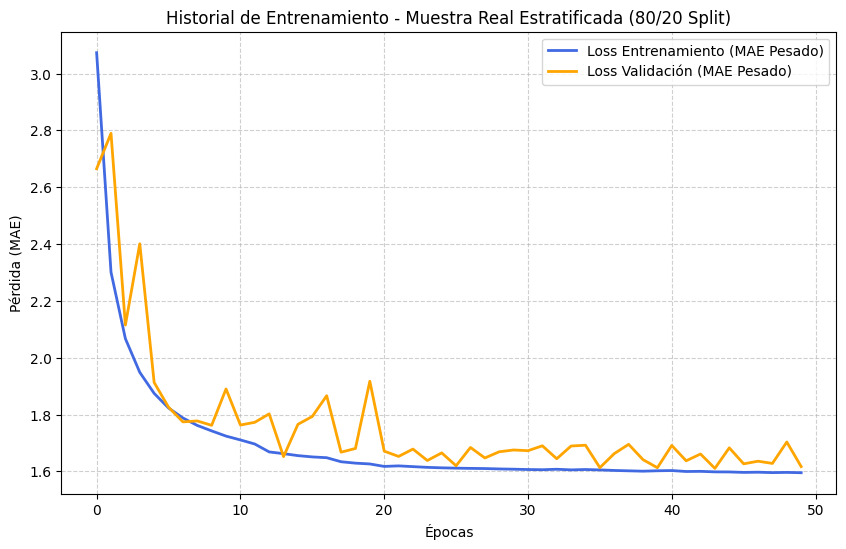

Evaluando el modelo en el conjunto de validación de forma estocástica...


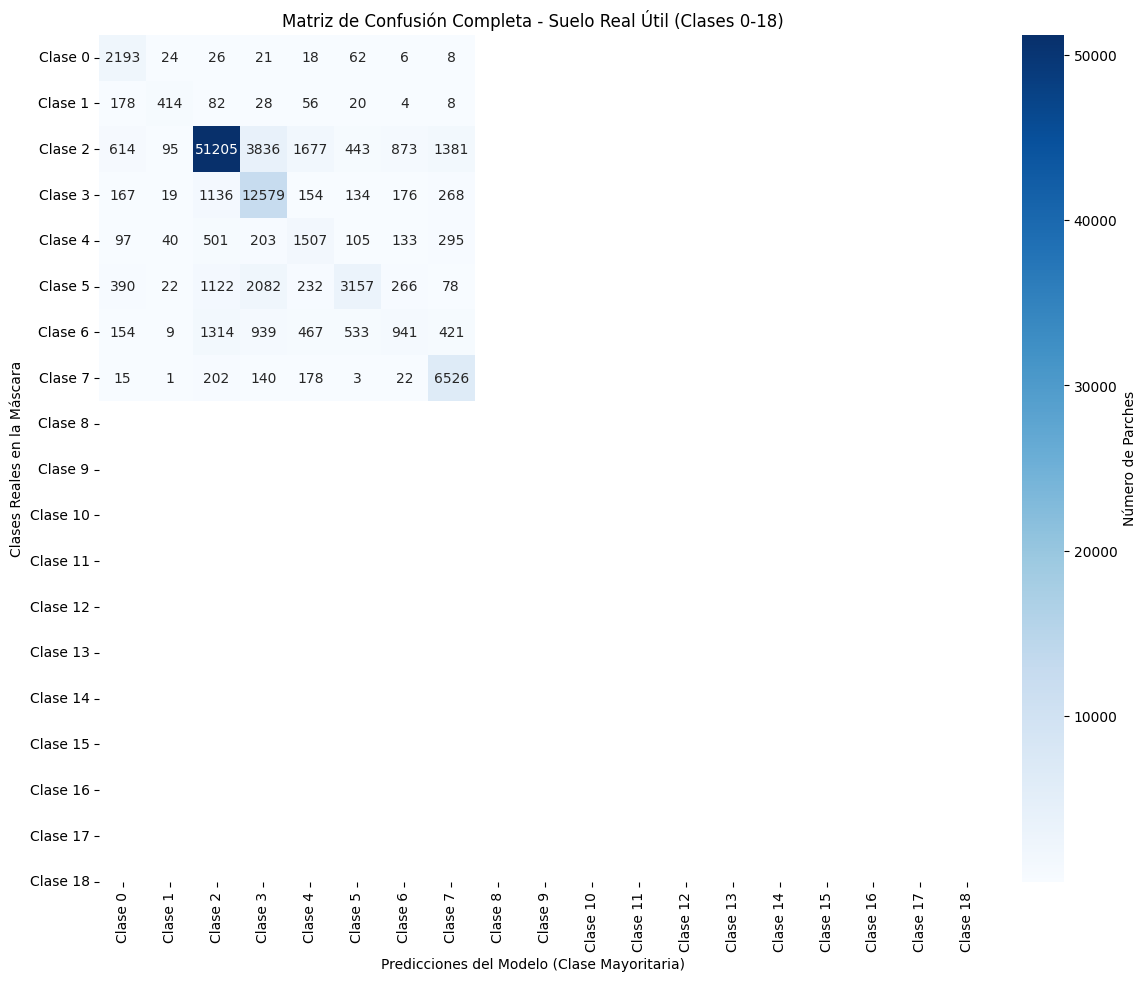


       MÉTRICAS FINALES (SITUACIÓN REAL VAL)
Accuracy General: 0.7852
Precision Macro:  0.6212
Recall Macro:     0.6545
F1-Score Macro:   0.6176


In [13]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("Dispositivos GPU disponibles:", tf.config.list_physical_devices('GPU'))

# =====================================================================
# 1. GENERADOR DE DATOS OPTIMIZADO (CON MAPEO DE MEMORIA ULTRA-RÁPIDO)
# =====================================================================
class GeneradorParchesTFG(Sequence):
    def __init__(self, carpeta_parches, lista_archivos, batch_size=64, shuffle=True):
        self.carpeta = carpeta_parches
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.archivos_X = lista_archivos
        self.num_clases = 19 
        self.indices = np.arange(len(self.archivos_X))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.archivos_X) / self.batch_size))

    def __getitem__(self, index):
        indices_batch = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        
        batch_X = []
        batch_Y_porcentajes = []
        
        for idx in indices_batch:
            nom_X = self.archivos_X[idx]
            nom_Y = nom_X.replace('_X.npy', '_Y.npy')
            
            try:
                parche_X = np.load(os.path.join(self.carpeta, nom_X), mmap_mode='r').astype(np.float32)
                parche_Y = np.load(os.path.join(self.carpeta, nom_Y), mmap_mode='r')
                
                if parche_X.shape[0] == 4:
                    parche_X = np.transpose(parche_X, (1, 2, 0))
                
                parche_X = parche_X[:48, :48, :]
                parche_Y = parche_Y[:48, :48]
                
                min_val = parche_X.min(axis=(0, 1), keepdims=True)
                max_val = parche_X.max(axis=(0, 1), keepdims=True)
                rango = max_val - min_val
                parche_X = np.where(rango > 0, (parche_X - min_val) / rango, 0.0)
                
                frecuencias = np.zeros(self.num_clases, dtype=np.float32)
                valores, counts = np.unique(parche_Y, return_counts=True)
                
                for v, c in zip(valores, counts):
                    if 0 <= v < self.num_clases:
                        frecuencias[v] = c
                
                suma_frec = np.sum(frecuencias)
                if float(suma_frec) == 0.0:
                    continue 
                    
                frecuencias = frecuencias / suma_frec
                
                batch_X.append(parche_X)
                batch_Y_porcentajes.append(frecuencias)
                
            except Exception:
                continue
            
        if len(batch_X) == 0:
            return (np.zeros((1, 48, 48, 4), dtype=np.float32), 
                    np.zeros((1, self.num_clases), dtype=np.float32))
            
        return np.array(batch_X), np.array(batch_Y_porcentajes)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


# =====================================================================
# 2. SELECCIÓN ALEATORIA ESTRATIFICADA (FILTRADO INMEDIATO DE CLASE 19)
# =====================================================================
# NUEVA RUTA ACTUALIZADA
carpeta_dataset = r"D:\Jorge\dataset_parches_50x50\dataset_parches_50x50"
ruta_guardado = r"D:\Jorge\modelocnnmlp.keras"

todos_los_X_total = [f for f in os.listdir(carpeta_dataset) if f.endswith('_X.npy')]

np.random.seed(4215) 
np.random.shuffle(todos_los_X_total)

archivos_prueba = []
categorias_predominantes = []
cupo_deseado = 500000  

for nom_X in todos_los_X_total:
    if len(archivos_prueba) >= cupo_deseado:
        break
        
    nom_Y = nom_X.replace('_X.npy', '_Y.npy')
    try:
        parche_Y = np.load(os.path.join(carpeta_dataset, nom_Y), mmap_mode='r')
        conteos = np.bincount(parche_Y.ravel(), minlength=20)
        clase_principal = np.argmax(conteos[:20])
        
        if clase_principal == 19:
            continue
            
        archivos_prueba.append(nom_X)
        categorias_predominantes.append(clase_principal)
    except Exception:
        continue

categorias_predominantes = np.array(categorias_predominantes)

archivos_train, archivos_val = train_test_split(
    archivos_prueba, 
    test_size=0.2, 
    stratify=categorias_predominantes, 
    random_state=42
)

generador_train = GeneradorParchesTFG(carpeta_dataset, archivos_train, batch_size=64, shuffle=True)
generador_val = GeneradorParchesTFG(carpeta_dataset, archivos_val, batch_size=64, shuffle=False)


# =====================================================================
# 3. ARQUITECTURA RED CONVOLUCIONAL (CON DROPOUT AJUSTADO, SIN DATA AUG)
# =====================================================================
def build_model_distribucion(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    x = layers.Dropout(0.2)(x)
    
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    x = layers.Dropout(0.3)(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs=inputs, outputs=outputs)

model = build_model_distribucion((48, 48, 4), 19)


# =====================================================================
# 4. FUNCIÓN DE PÉRDIDA CON PESOS MATEMÁTICOS SUAVIZADOS
# =====================================================================
PESOS_REALES_MESETA = tf.constant([
    4.5,  # Clase 0
    8.3,  # Clase 1 
    1.0,  # Clase 2 (Base dominante)
    2.0,  # Clase 3
    4.2,  # Clase 4
    2.7,  # Clase 5
    3.3,  # Clase 6
    2.9,  # Clase 7
    0.0,  # Clase 8 
    0.0,  # Clase 9 
    0.0,  # Clase 10 
    10.0, # Clase 11 (Máximo castigo controlado para romper el estancamiento)
    0.0,  # Clase 12 
    0.0,  # Clase 13 
    0.0,  # Clase 14 
    0.0,  # Clase 15 
    0.0,  # Clase 16 
    0.0,  # Clase 17 
    0.0   # Clase 18 
], dtype=tf.float32)

def categorical_crossentropy_pesada(y_true, y_pred):
    smooth = 1e-5
    y_pred = tf.clip_by_value(y_pred, smooth, 1.0 - smooth)
    cce_por_parche = -y_true * tf.math.log(y_pred)
    cce_pesada = cce_por_parche * PESOS_REALES_MESETA
    return tf.reduce_mean(tf.reduce_sum(cce_pesada, axis=-1))

# OPTIMIZACIÓN: Reducido el learning_rate inicial a 1e-4 para dar estabilidad
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4, clipnorm=0.5),
    loss=categorical_crossentropy_pesada, 
    metrics=['mae', 'accuracy'] 
)

mis_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1),
    callbacks.ModelCheckpoint(filepath=ruta_guardado, monitor='val_loss', save_best_only=True, verbose=1)
]


# =====================================================================
# 5. EJECUCIÓN DEL ENTRENAMIENTO (CON PRE-CARGA PARALELA ACTIVADA)
# =====================================================================
print("Arrancando el entrenamiento estratégico...")
history = model.fit(
    generador_train,
    validation_data=generador_val,
    epochs=50,
    callbacks=mis_callbacks,
    workers=4,                  
    use_multiprocessing=False
)


# =====================================================================
# 6. EVALUACIÓN DE MÉTRICAS GLOBALES Y GRÁFICAS (CON VALIDACIÓN 20K)
# =====================================================================
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label="Loss Entrenamiento (MAE Pesado)", color='royalblue', linewidth=2)
plt.plot(history.history['val_loss'], label="Loss Validación (MAE Pesado)", color='orange', linewidth=2)
plt.title("Historial de Entrenamiento - Muestra Real Estratificada (80/20 Split)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (MAE)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Evaluando el modelo en el conjunto de validación de forma estocástica...", flush=True)
y_true_list = []
y_pred_list = []

for i in range(len(generador_val)):
    bx, by = generador_val[i]
    preds = model.predict(bx, verbose=0)
    y_true_list.append(by)
    y_pred_list.append(preds)

y_true = np.concatenate(y_true_list, axis=0)
y_pred = np.concatenate(y_pred_list, axis=0)

y_true_classes = np.argmax(y_true, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

clases_nombres = [f"Clase {i}" for i in range(19)]
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(14, 11))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=clases_nombres, 
    yticklabels=clases_nombres,
    cbar_kws={'label': 'Número de Parches'}
)
plt.xlabel('Predicciones del Modelo (Clase Mayoritaria)')
plt.ylabel('Clases Reales en la Máscara')
plt.title('Matriz de Confusión Completa - Suelo Real Útil (Clases 0-18)')
plt.show()

print("\n       MÉTRICAS FINALES (SITUACIÓN REAL VAL)")
print("="*40)
print(f"Accuracy General: {accuracy_score(y_true_classes, y_pred_classes):.4f}")
print(f"Precision Macro:  {precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"Recall Macro:     {recall_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"F1-Score Macro:   {f1_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print("="*40)

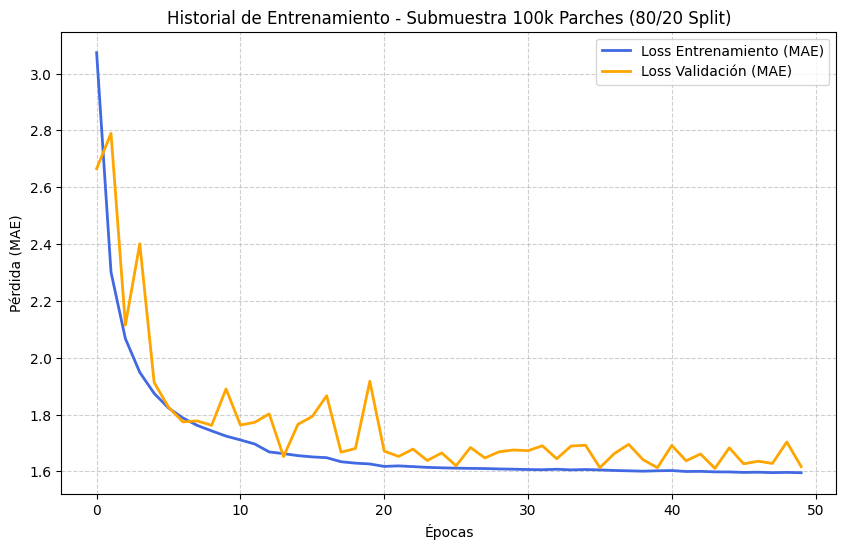

Evaluando el modelo en el conjunto de validación estocástico...


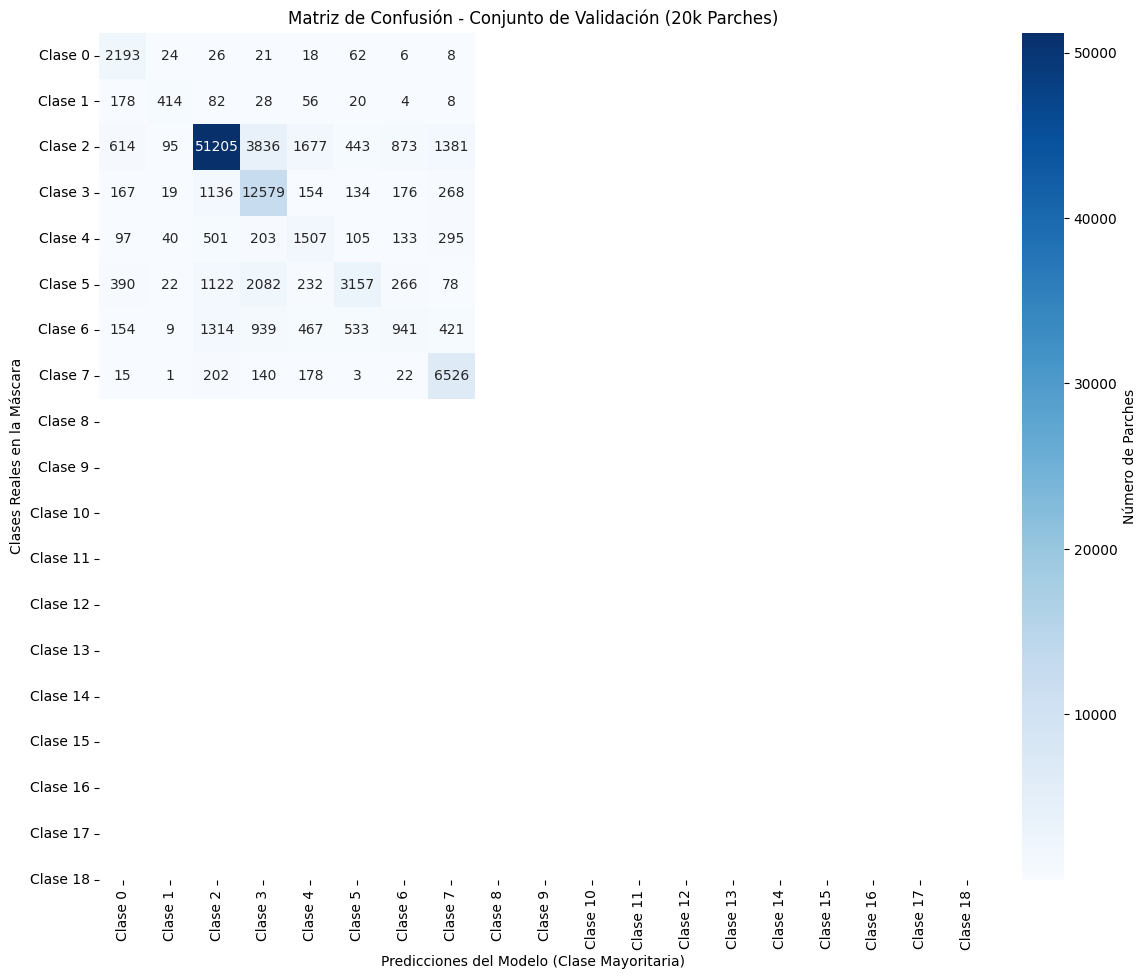

Accuracy General: 0.7852
Precision Macro:  0.6212
Recall Macro:     0.6545
F1-Score Macro:   0.6176


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# 5. GRÁFICAS DE RENDIMIENTO Y EVALUACIÓN (Validación 20k)
# ==========================================

# 1. Gráfica de la curva de pérdida (MAE)
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label="Loss Entrenamiento (MAE)", color='royalblue', linewidth=2)
plt.plot(history.history['val_loss'], label="Loss Validación (MAE)", color='orange', linewidth=2)
plt.title("Historial de Entrenamiento - Submuestra 500k Parches (80/20 Split)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (MAE)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Extracción controlada de Ground Truth y Predicciones usando el generador de validación
print("Evaluando el modelo en el conjunto de validación estocástico...")
y_true_list = []
y_pred_list = []

for i in range(len(generador_val)):
    bx, by = generador_val[i]
    preds = model.predict(bx, verbose=0)
    y_true_list.append(by)
    y_pred_list.append(preds)

y_true = np.concatenate(y_true_list, axis=0)
y_pred = np.concatenate(y_pred_list, axis=0)

# Al trabajar con porcentajes, obtenemos la clase predominante (mayoritaria) para métricas estándar
y_true_classes = np.argmax(y_true, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# 3. Representación de la Matriz de Confusión
clases_nombres = [f"Clase {i}" for i in range(19)]
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(14, 11))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=clases_nombres, 
    yticklabels=clases_nombres,
    cbar_kws={'label': 'Número de Parches'}
)
plt.xlabel('Predicciones del Modelo (Clase Mayoritaria)')
plt.ylabel('Clases Reales en la Máscara')
plt.title('Matriz de Confusión - Conjunto de Validación (20k Parches)')
plt.show()

# 4. Cálculo e impresión de métricas de rendimiento globales
print(f"Accuracy General: {accuracy_score(y_true_classes, y_pred_classes):.4f}")
print(f"Precision Macro:  {precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"Recall Macro:     {recall_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"F1-Score Macro:   {f1_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")

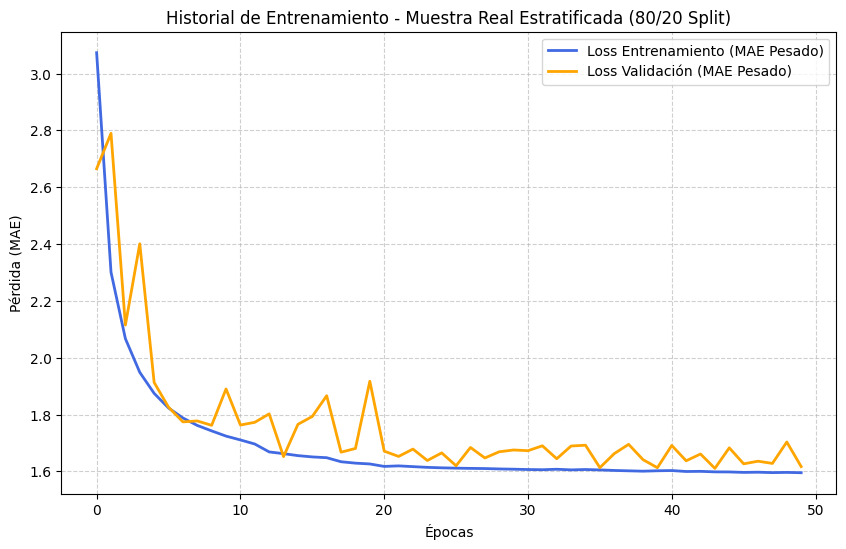

Evaluando el modelo en el conjunto de validación de forma estocástica...


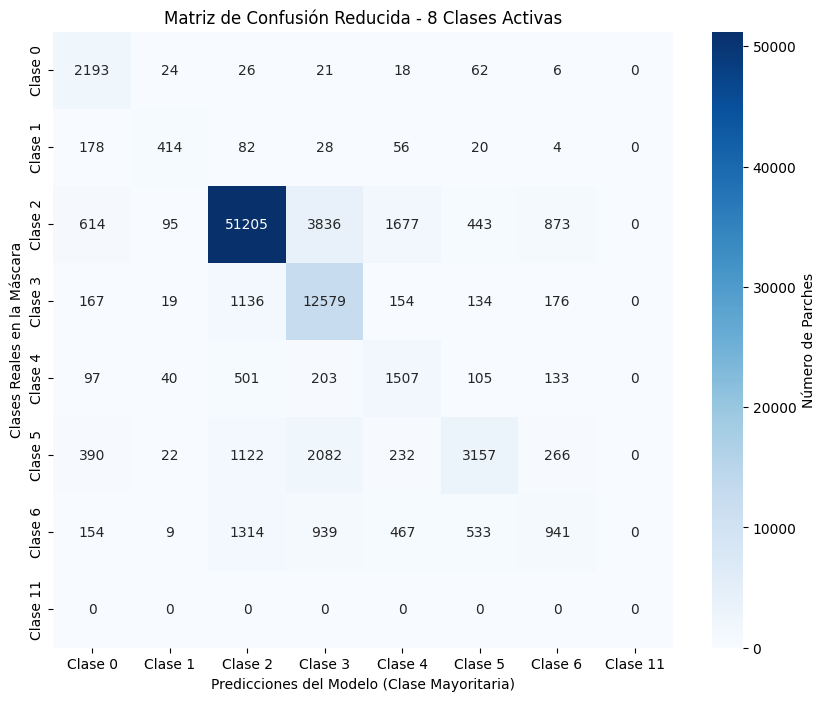


       MÉTRICAS FINALES (SITUACIÓN REAL VAL)
Accuracy General: 0.7852
Precision Macro:  0.6212
Recall Macro:     0.6545
F1-Score Macro:   0.6176


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label="Loss Entrenamiento (MAE Pesado)", color='royalblue', linewidth=2)
plt.plot(history.history['val_loss'], label="Loss Validación (MAE Pesado)", color='orange', linewidth=2)
plt.title("Historial de Entrenamiento - Muestra Real Estratificada (80/20 Split)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (MAE)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Evaluando el modelo en el conjunto de validación de forma estocástica...", flush=True)
y_true_list = []
y_pred_list = []

for i in range(len(generador_val)):
    bx, by = generador_val[i]
    preds = model.predict(bx, verbose=0)
    y_true_list.append(by)
    y_pred_list.append(preds)

y_true = np.concatenate(y_true_list, axis=0)
y_pred = np.concatenate(y_pred_list, axis=0)

y_true_classes = np.argmax(y_true, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

clases_usadas = [0, 1, 2, 3, 4, 5, 6, 11]
clases_nombres = [f"Clase {i}" for i in clases_usadas]

conf_matrix = confusion_matrix(y_true_classes, y_pred_classes, labels=clases_usadas)

plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=clases_nombres, 
    yticklabels=clases_nombres,
    cbar_kws={'label': 'Número de Parches'}
)
plt.xlabel('Predicciones del Modelo (Clase Mayoritaria)')
plt.ylabel('Clases Reales en la Máscara')
plt.title('Matriz de Confusión Reducida - 8 Clases Activas')
plt.show()

print("\n       MÉTRICAS FINALES (SITUACIÓN REAL VAL)")
print("="*40)
print(f"Accuracy General: {accuracy_score(y_true_classes, y_pred_classes):.4f}")
print(f"Precision Macro:  {precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"Recall Macro:     {recall_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"F1-Score Macro:   {f1_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print("="*40)

In [16]:
# =====================================================================
# 2. SELECCIÓN ALEATORIA ESTRATIFICADA (REPARTO EXACTO EN DISCO)
# =====================================================================
carpeta_dataset = r"D:\Jorge\dataset_parches_50x50\dataset_parches_50x50"
ruta_guardado = r"D:\Jorge\modelocnnmlp.keras"

# 1. Leemos TODOS los archivos disponibles (el millón completo)
todos_los_X_total = [f for f in os.listdir(carpeta_dataset) if f.endswith('_X.npy')]

# Mezclamos la lista completa una sola vez para que la separación sea aleatoria y justa
np.random.seed(4215) 
np.random.shuffle(todos_los_X_total)

# 2. Procesamos los primeros archivos buscando el bloque para TRAIN/VAL (Hasta juntar 500k válidos)
archivos_bloque_train_val = []
categorias_train_val = []
cupo_train_val = 500000  

indice_lectura = 0

for nom_X in todos_los_X_total:
    indice_lectura += 1
    if len(archivos_bloque_train_val) >= cupo_train_val:
        break
        
    nom_Y = nom_X.replace('_X.npy', '_Y.npy')
    try:
        parche_Y = np.load(os.path.join(carpeta_dataset, nom_Y), mmap_mode='r')
        conteos = np.bincount(parche_Y.ravel(), minlength=20)
        clase_principal = np.argmax(conteos[:20])
        
        if clase_principal == 19:
            continue
            
        archivos_bloque_train_val.append(nom_X)
        categorias_train_val.append(clase_principal)
    except Exception:
        continue

# 3. Cogemos los datos restantes (del millón) para buscar los 100k de TEST puro
# Empezamos a buscar estrictamente desde donde se quedó el bucle anterior
archivos_bloque_test = []
categorias_test = []
cupo_test = 100000

for nom_X in todos_los_X_total[indice_lectura:]:
    if len(archivos_bloque_test) >= cupo_test:
        break
        
    nom_Y = nom_X.replace('_X.npy', '_Y.npy')
    try:
        parche_Y = np.load(os.path.join(carpeta_dataset, nom_Y), mmap_mode='r')
        conteos = np.bincount(parche_Y.ravel(), minlength=20)
        clase_principal = np.argmax(conteos[:20])
        
        if clase_principal == 19:
            continue
            
        archivos_bloque_test.append(nom_X)
        categorias_test.append(clase_principal)
    except Exception:
        continue


# 4. Dividimos el primer bloque (los 500k) en Train (80%) y Validación (20%)
categorias_train_val = np.array(categorias_train_val)

archivos_train, archivos_val = train_test_split(
    archivos_bloque_train_val, 
    test_size=0.2, # El 20% de 500k son 100k para validación
    stratify=categorias_train_val, 
    random_state=42
)

# 5. Creamos los tres generadores independientes
generador_train = GeneradorParchesTFG(carpeta_dataset, archivos_train, batch_size=64, shuffle=True)
generador_val = GeneradorParchesTFG(carpeta_dataset, archivos_val, batch_size=64, shuffle=False)
generador_test = GeneradorParchesTFG(carpeta_dataset, archivos_bloque_test, batch_size=64, shuffle=False)

print(f"--- DISTRIBUCIÓN FINAL DE LOS DATOS ---")
print(f"Total datos leídos del disco para Train/Val: {indice_lectura}")
print(f"-> Quedan para Entrenamiento: {len(archivos_train)} parches.")
print(f"-> Quedan para Validación (en fit): {len(archivos_val)} parches.")
print(f"-> Quedan para Test Puro (Métricas/Matriz): {len(archivos_bloque_test)} parches.")

KeyboardInterrupt: 

In [22]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Verificar que la GPU esté lista
print("Dispositivos GPU disponibles:", tf.config.list_physical_devices('GPU'))

# Rutas de carpetas y modelo
carpeta_dataset = r"D:\Jorge\dataset_parches_50x50\dataset_parches_50x50"
ruta_modelo = r"D:\Jorge\modelocnnmlp.keras"

# =====================================================================
# 1. SELECCIÓN Y FILTRADO DIRECTO EN MEMORIA (RANGO 500K - 600K)
# =====================================================================
print("Leyendo lista completa de archivos del disco...")
todos_los_X_total = [f for f in os.listdir(carpeta_dataset) if f.endswith('_X.npy')]

# Mezclamos con la misma semilla exacta del entrenamiento original
np.random.seed(4215) 
np.random.shuffle(todos_los_X_total)

# Recortamos la lista al rango que deseas evaluar
bloque_candidatos = todos_los_X_total[500000:600000]

X_test_list = []
y_true_list = []

print(f"Filtrando y cargando parches válidos dentro de las {len(bloque_candidatos)} muestras...")

for nom_X in bloque_candidatos:
    nom_Y = nom_X.replace('_X.npy', '_Y.npy')
    try:
        # Carga rápida mapeada en memoria solo para validar la clase principal
        parche_Y_fast = np.load(os.path.join(carpeta_dataset, nom_Y), mmap_mode='r')
        conteos = np.bincount(parche_Y_fast.ravel(), minlength=20)
        clase_principal = np.argmax(conteos[:20])
        
        # FILTRO CRÍTICO: Si la clase mayoritaria es 19, la descartamos por completo
        if clase_principal == 19:
            continue
            
        # Si es válido, ahora sí cargamos las matrices completas a memoria
        parche_X = np.load(os.path.join(carpeta_dataset, nom_X)).astype(np.float32)
        parche_Y = np.load(os.path.join(carpeta_dataset, nom_Y))
        
        # --- Preprocesamiento idéntico al que usaba tu modelo ---
        if parche_X.shape[0] == 4:
            parche_X = np.transpose(parche_X, (1, 2, 0))
            
        parche_X = parche_X[:48, :48, :]
        parche_Y = parche_Y[:48, :48]
        
        # Normalización Min-Max por parche
        min_val = parche_X.min(axis=(0, 1), keepdims=True)
        max_val = parche_X.max(axis=(0, 1), keepdims=True)
        rango = max_val - min_val
        parche_X = np.where(rango > 0, (parche_X - min_val) / rango, 0.0)
        
        # Convertir la máscara de píxeles en distribución de frecuencias (un vector de 19)
        frecuencias = np.zeros(19, dtype=np.float32)
        valores, counts = np.unique(parche_Y, return_counts=True)
        for v, c in zip(valores, counts):
            if 0 <= v < 19:
                frecuencias[v] = c
                
        suma_frec = np.sum(frecuencias)
        if float(suma_frec) == 0.0:
            continue
            
        frecuencias = frecuencias / suma_frec
        
        # Guardamos en nuestras listas de memoria
        X_test_list.append(parche_X)
        y_true_list.append(frecuencias)
        
    except Exception:
        continue

# Convertimos las listas a tensores NumPy listos para la GPU
X_test = np.array(X_test_list)
y_true = np.array(y_true_list)

print(f"-> Proceso terminado. Se usarán {X_test.shape[0]} parches limpios para el testeo.")


# =====================================================================
# 2. CARGA DEL MODELO E INFERENCIA DIRECTA EN GPU
# =====================================================================
print(f"Cargando el modelo desde {ruta_modelo}...")
# compile=False ahorra tener que pasarle funciones de pérdida customizadas al cargar
model = tf.keras.models.load_model(ruta_modelo, compile=False)

print("Iniciando predicciones en ráfaga continua sobre la GPU...")
# Al pasar el array de NumPy directo, TensorFlow gestiona los lotes a nivel de hardware al instante
y_pred = model.predict(X_test, batch_size=64, verbose=1)

# Obtenemos los índices de las clases dominantes (de 0 a 18)
y_true_classes = np.argmax(y_true, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)


# =====================================================================
# 3. MATRIZ DE CONFUSIÓN REDUCIDA (8 CLASES) Y MÉTRICAS
# =====================================================================
# Filtramos únicamente tus 8 clases con peso real mayor a 0.0
clases_usadas = [0, 1, 2, 3, 4, 5, 6, 11]
clases_nombres = [f"Clase {i}" for i in clases_usadas]

# El parámetro labels asegura que la matriz sea de 8x8 e ignore el resto de categorías
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes, labels=clases_usadas)

plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=clases_nombres, 
    yticklabels=clases_nombres,
    cbar_kws={'label': 'Número de Parches'}
)
plt.xlabel('Predicciones del Modelo (Clase Mayoritaria)')
plt.ylabel('Clases Reales en la Máscara')
plt.title('Matriz de Confusión Reducida - Rango 500k-600k (Filtrado sin Clase 19)')
plt.show()

print("\n========================================")
print("   MÉTRICAS FINALES DE INFERENCIA (TEST)")
print("========================================")
print(f"Accuracy General: {accuracy_score(y_true_classes, y_pred_classes):.4f}")
print(f"Precision Macro:  {precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"Recall Macro:     {recall_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"F1-Score Macro:   {f1_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print("========================================")

Dispositivos GPU disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Leyendo lista completa de archivos del disco...
Filtrando y cargando parches válidos dentro de las 100000 muestras...


KeyboardInterrupt: 